# ДЗ
1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа).
2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

Длина наиболее протяженного участка: 312.54


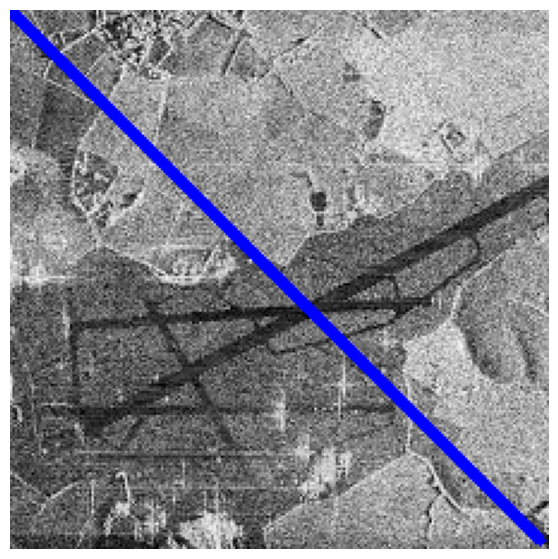

In [4]:
# 1. Поиск наиболее протяженной линии с помощью преобразования Хафа

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(image_gray, 80, 180, apertureSize=3)

lines = cv2.HoughLinesP(
    edges, 1, np.pi / 180,
    threshold=35,
    minLineLength=70,
    maxLineGap=10
)

max_length = 0
best_line = None

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if length > max_length:
            max_length = length
            best_line = (x1, y1, x2, y2)

result = image.copy()

if best_line is not None:
    x1, y1, x2, y2 = best_line
    cv2.line(result, (x1, y1), (x2, y2), (255, 0, 0), 3)

print('Длина наиболее протяженного участка:', round(max_length, 2))

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Порог Оцу: 129.0


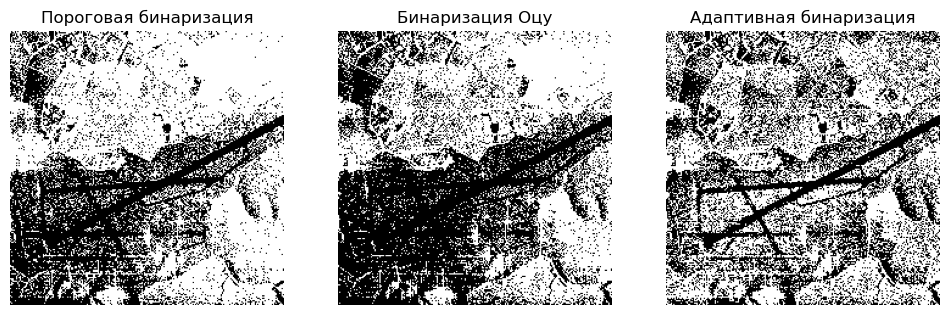

In [5]:
# 2. Исследование методов бинаризации

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

T = 115
bin_img = np.zeros_like(image_gray)
bin_img[image_gray >= T] = 255

T_otsu, otsu = cv2.threshold(
    image_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

adaptive = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    51, 7
)

print('Порог Оцу:', T_otsu)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(bin_img, cmap='gray')
plt.title('Пороговая бинаризация')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(otsu, cmap='gray')
plt.title('Бинаризация Оцу')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')

plt.show()

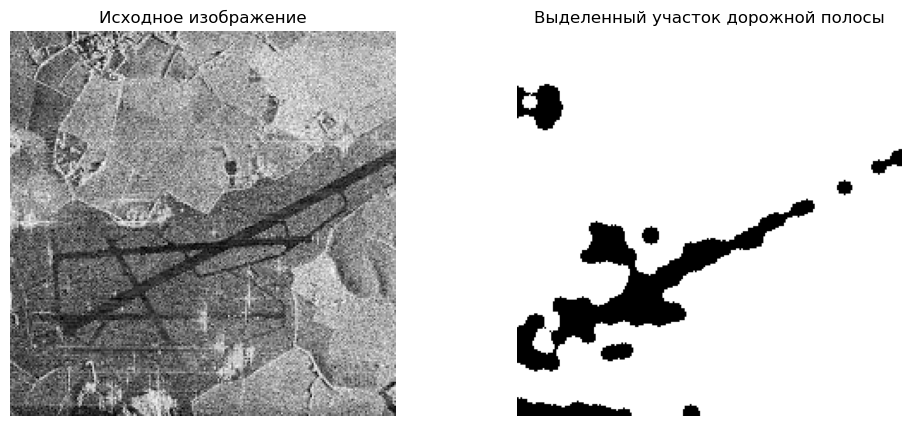

In [6]:
# Выделение дорожного участка

road = otsu.copy()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, kernel, iterations=1)
road = cv2.morphologyEx(road, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(road, cmap='gray')
plt.title('Выделенный участок дорожной полосы')
plt.axis('off')

plt.show()